# Benchmark Riguroso de Inferencia y Eficiencia Computacional - PIDNet

Este notebook proporciona un suite independiente y técnicamente estandarizado para medir la velocidad de inferencia, latencia por etapas y escalabilidad por lotes (*batch size*) de la arquitectura **PIDNet** en GPU y CPU.

### Metodología de Medición Rigurosa:
1. **Aislamiento de I/O y Gráficos**: Evaluación puramente en memoria eliminando las sobrecargas de lectura de disco y renderizado gráfico.
2. **Fase de Calentamiento (*Warm-up*)**: Descarte de 30 iteraciones iniciales para estabilizar cachés de CUDA y frecuencias de reloj de la GPU.
3. **Sincronización Estricta de GPU**: Uso de `torch.cuda.Event(enable_timing=True)` y `torch.cuda.synchronize()` para mediciones precisas de hardware a nivel de microsegundos.
4. **Métricas Desglosadas**:
   - Latencia Media, Mediana, Desviación Estándar ($\pm \sigma$), Percentiles $P_{95}$ y $P_{99}$.
   - Rendimiento en cuadros por segundo ($	ext{FPS} = 1000 / 	ext{latencia}$).
   - Comparación de precisión: **FP32** vs **Automatic Mixed Precision (AMP FP16)**.
   - Latencia del **Pipeline Completo End-to-End** (Preprocesamiento + Forward + Upsampling Bilineal + Argmax).
   - Análisis de escalabilidad por tamaño de lote ($BS \in \{1, 2, 4, 8\}$).
5. **Exportación para Paper IEEE**: Generación automática de la fila formateada en LaTeX para la **Tabla II** (`tab:results_comparison`) de `main.tex`.


In [ ]:
# ==== Solo para ejecutar en Colab / Local ========
try:
    from google.colab import drive
    import os
    import sys

    # 1. Montar Google Drive
    drive.mount('/content/drive')

    # 2. Definir la ruta a tu proyecto dentro de Drive
    project_path = '/content/drive/MyDrive/tp_computer_vision_ii'
    notebook_dir = os.path.join(project_path, 'src', 'pidnet')

    # 3. Movernos al directorio donde está el notebook para que las rutas relativas funcionen
    os.chdir(notebook_dir)

    # 4. Agregar la ruta a sys.path para que Python encuentre la carpeta "models"
    if notebook_dir not in sys.path:
        sys.path.append(notebook_dir)

    print("Directorio actual en Colab:", os.getcwd())
    IN_COLAB = True

except:
    IN_COLAB = False
    import os, sys
    current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in locals() else os.getcwd()
    if current_dir not in sys.path:
        sys.path.append(current_dir)
    print("Ejecutando en entorno Local. Directorio actual:", os.getcwd())


Mounted at /content/drive
Directorio actual en Colab: /content/drive/MyDrive/tp_computer_vision_ii/src/pidnet


In [2]:
# ==============================================================================
# 1. PARÁMETROS CONFIGURABLES DEL BENCHMARK
# ==============================================================================

# ─── Ruta del Checkpoint y Arquitectura ──────────────────────────────────────
CHECKPOINT_PATH = "best_trained/best_pidnet_S.pth"
VARIANT         = "S"       # Variante de arquitectura ('S', 'M' o 'L')
NUM_CLASSES     = 2         # Número de clases (0: Fondo, 1: Grieta)

# ─── Configuración de la Medición ─────────────────────────────────────────────
INPUT_HEIGHT    = 512       # Altura estándar de evaluación
INPUT_WIDTH     = 512       # Ancho estándar de evaluación
WARMUP_ITERS    = 30        # Iteraciones descartadas de estabilización
BENCHMARK_ITERS = 150       # Iteraciones para recolección de métricas estadísticas

# ─── Análisis de Escalabilidad por Batch ───────────────────────────────────────
BATCH_SIZES_TO_TEST = [1, 2, 4, 8]


In [3]:
# ==============================================================================
# 2. IMPORTS, DISPOSITIVO Y RESOLUCIÓN DE RUTAS
# ==============================================================================
import os
import sys
import time
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from models.pidnet import PIDNet

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de cómputo : {device}")
if device.type == 'cuda':
    print(f"GPU detectada          : {torch.cuda.get_device_name(0)}")
    print(f"Memoria VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

def resolve_path(path_str):
    """
    Resuelve rutas relativas cross-platform tanto en Colab como en Local.
    """
    clean_p = path_str.replace('\\', '/')
    p = Path(clean_p)
    if p.exists():
        return str(p)
    for root in ['.', '..', '../..', 'src/pidnet', 'tp_computer_vision_ii']:
        candidate = Path(root) / clean_p
        if candidate.exists():
            return str(candidate.resolve())
    return str(p)


Dispositivo de cómputo : cuda
GPU detectada          : Tesla T4
Memoria VRAM disponible: 14.56 GB


In [4]:
# ==============================================================================
# 3. CARGA Y PREPARACIÓN DEL MODELO PIDNET
# ==============================================================================

def load_benchmark_model(checkpoint_path, variant="S", num_classes=2, device="cpu"):
    """
    Instancia la arquitectura PIDNet y carga los pesos del checkpoint.
    """
    if variant == 'S':
        model = PIDNet(m=2, n=3, num_classes=num_classes, planes=32, ppm_planes=96, head_planes=128, augment=True)
    elif variant == 'M':
        model = PIDNet(m=2, n=3, num_classes=num_classes, planes=64, ppm_planes=96, head_planes=128, augment=True)
    elif variant == 'L':
        model = PIDNet(m=3, n=4, num_classes=num_classes, planes=64, ppm_planes=112, head_planes=256, augment=True)
    else:
        raise ValueError(f"Variante '{variant}' no válida.")

    resolved_ckpt = resolve_path(checkpoint_path)
    if os.path.exists(resolved_ckpt):
        ckpt = torch.load(resolved_ckpt, map_location='cpu')
        state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
        state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
        model.load_state_dict(state_dict, strict=False)
        print(f"Checkpoint cargado exitosamente desde: {resolved_ckpt}")
        if isinstance(ckpt, dict) and 'epoch' in ckpt:
            print(f"  -> Época: {ckpt.get('epoch', 'N/A')} | Val Crack IoU: {ckpt.get('val_metrics', {}).get('crack_iou', 'N/A')}")
    else:
        print(f"[AVISO] No se encontró {checkpoint_path}. Evaluando con inicialización en memoria.")

    model.to(device)
    model.eval()
    return model

model = load_benchmark_model(CHECKPOINT_PATH, variant=VARIANT, num_classes=NUM_CLASSES, device=device)

# Estadísticas de complejidad del modelo
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
param_mb = (total_params * 4) / (1024 * 1024)

print(f"\n--- Complejidad de la Arquitectura PIDNet-{VARIANT} ---")
print(f"Parámetros Totales     : {total_params / 1e6:.2f} M ({total_params:,} parámetros)")
print(f"Parámetros Entrenables : {trainable_params / 1e6:.2f} M")
print(f"Tamaño en VRAM (FP32)  : {param_mb:.2f} MB")


Checkpoint cargado exitosamente desde: best_trained/best_pidnet_S.pth
  -> Época: 29 | Val Crack IoU: 0.6660165190696716

--- Complejidad de la Arquitectura PIDNet-S ---
Parámetros Totales     : 7.72 M (7,716,549 parámetros)
Parámetros Entrenables : 7.72 M
Tamaño en VRAM (FP32)  : 29.44 MB


In [5]:
# ==============================================================================
# 4. BENCHMARK: FORWARD PASS PURO EN GPU / CPU (FP32 vs AMP FP16)
# ==============================================================================

dummy_input_single = torch.randn(1, 3, INPUT_HEIGHT, INPUT_WIDTH, device=device)

def run_forward_benchmark(model, input_tensor, device, warmup=30, iters=150, use_amp=False):
    """
    Ejecuta el protocolo de medición de Forward Pass con CUDA Events o time.perf_counter().
    """
    model.eval()
    amp_enabled = (use_amp and device.type == 'cuda')

    # 1. Warm-up
    with torch.inference_mode():
        with torch.amp.autocast('cuda', enabled=amp_enabled):
            for _ in range(warmup):
                _ = model(input_tensor)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # 2. Medición estricta
    latencies = []
    with torch.inference_mode():
        with torch.amp.autocast('cuda', enabled=amp_enabled):
            for _ in range(iters):
                if device.type == 'cuda':
                    start_evt = torch.cuda.Event(enable_timing=True)
                    end_evt = torch.cuda.Event(enable_timing=True)
                    start_evt.record()
                    _ = model(input_tensor)
                    end_evt.record()
                    torch.cuda.synchronize()
                    latencies.append(start_evt.elapsed_time(end_evt)) # ms
                else:
                    t0 = time.perf_counter()
                    _ = model(input_tensor)
                    t1 = time.perf_counter()
                    latencies.append((t1 - t0) * 1000.0)

    latencies = np.array(latencies)
    return {
        'mean': np.mean(latencies),
        'median': np.median(latencies),
        'std': np.std(latencies),
        'p95': np.percentile(latencies, 95),
        'p99': np.percentile(latencies, 99),
        'min': np.min(latencies),
        'max': np.max(latencies),
        'fps': 1000.0 / np.mean(latencies),
        'raw_latencies': latencies
    }

print("Ejecutando Benchmark: Forward Pass Puro en FP32 (BS = 1, 512x512)...")
stats_fp32 = run_forward_benchmark(model, dummy_input_single, device, warmup=WARMUP_ITERS, iters=BENCHMARK_ITERS, use_amp=False)

print(f"\n▶ Resultados Forward Pass (FP32):")
print(f"   Latencia Media   : {stats_fp32['mean']:.2f} ms ± {stats_fp32['std']:.2f} ms")
print(f"   Latencia Mediana : {stats_fp32['median']:.2f} ms (p95: {stats_fp32['p95']:.2f} ms | p99: {stats_fp32['p99']:.2f} ms)")
print(f"   Rango [Min, Max] : [{stats_fp32['min']:.2f} ms, {stats_fp32['max']:.2f} ms]")
print(f"   Throughput (FPS) : {stats_fp32['fps']:.2f} FPS")

stats_fp16 = None
if device.type == 'cuda':
    print("\nEjecutando Benchmark: Forward Pass Puro con AMP FP16...")
    stats_fp16 = run_forward_benchmark(model, dummy_input_single, device, warmup=WARMUP_ITERS, iters=BENCHMARK_ITERS, use_amp=True)
    print(f"▶ Resultados Forward Pass (AMP FP16):")
    print(f"   Latencia Media   : {stats_fp16['mean']:.2f} ms ± {stats_fp16['std']:.2f} ms")
    print(f"   Latencia Mediana : {stats_fp16['median']:.2f} ms (p95: {stats_fp16['p95']:.2f} ms | p99: {stats_fp16['p99']:.2f} ms)")
    print(f"   Throughput (FPS) : {stats_fp16['fps']:.2f} FPS")
    print(f"   Speedup FP16     : {stats_fp32['mean'] / stats_fp16['mean']:.2f}x vs FP32")


Ejecutando Benchmark: Forward Pass Puro en FP32 (BS = 1, 512x512)...

▶ Resultados Forward Pass (FP32):
   Latencia Media   : 11.62 ms ± 2.66 ms
   Latencia Mediana : 12.16 ms (p95: 16.28 ms | p99: 18.18 ms)
   Rango [Min, Max] : [8.49 ms, 19.78 ms]
   Throughput (FPS) : 86.06 FPS

Ejecutando Benchmark: Forward Pass Puro con AMP FP16...
▶ Resultados Forward Pass (AMP FP16):
   Latencia Media   : 17.20 ms ± 3.23 ms
   Latencia Mediana : 16.09 ms (p95: 22.42 ms | p99: 30.12 ms)
   Throughput (FPS) : 58.15 FPS
   Speedup FP16     : 0.68x vs FP32


In [6]:
# ==============================================================================
# 5. BENCHMARK: PIPELINE COMPLETO END-TO-END
# ==============================================================================
# Evalúa el ciclo completo en GPU:
# Forward Pass -> Interpolación Bilineal a Resolución Original (512x512) -> Softmax / Argmax

def run_pipeline_e2e_benchmark(model, input_tensor, device, warmup=30, iters=150, use_amp=False):
    model.eval()
    amp_enabled = (use_amp and device.type == 'cuda')
    orig_h, orig_w = input_tensor.shape[2], input_tensor.shape[3]

    # Warm-up
    with torch.inference_mode():
        with torch.amp.autocast('cuda', enabled=amp_enabled):
            for _ in range(warmup):
                out = model(input_tensor)
                pred = F.interpolate(out[1], size=(orig_h, orig_w), mode='bilinear', align_corners=True)
                mask = pred.argmax(dim=1)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Medición
    latencies = []
    with torch.inference_mode():
        with torch.amp.autocast('cuda', enabled=amp_enabled):
            for _ in range(iters):
                if device.type == 'cuda':
                    start_evt = torch.cuda.Event(enable_timing=True)
                    end_evt = torch.cuda.Event(enable_timing=True)
                    start_evt.record()
                    out = model(input_tensor)
                    pred = F.interpolate(out[1], size=(orig_h, orig_w), mode='bilinear', align_corners=True)
                    mask = pred.argmax(dim=1)
                    end_evt.record()
                    torch.cuda.synchronize()
                    latencies.append(start_evt.elapsed_time(end_evt))
                else:
                    t0 = time.perf_counter()
                    out = model(input_tensor)
                    pred = F.interpolate(out[1], size=(orig_h, orig_w), mode='bilinear', align_corners=True)
                    mask = pred.argmax(dim=1)
                    t1 = time.perf_counter()
                    latencies.append((t1 - t0) * 1000.0)

    latencies = np.array(latencies)
    return {
        'mean': np.mean(latencies),
        'median': np.median(latencies),
        'std': np.std(latencies),
        'fps': 1000.0 / np.mean(latencies),
        'raw_latencies': latencies
    }

print("Ejecutando Benchmark: Pipeline Completo End-to-End (BS = 1, 512x512)...")
stats_e2e = run_pipeline_e2e_benchmark(model, dummy_input_single, device, warmup=WARMUP_ITERS, iters=BENCHMARK_ITERS, use_amp=(device.type == 'cuda'))

print(f"▶ Resultados Pipeline Completo End-to-End:")
print(f"   Latencia Media   : {stats_e2e['mean']:.2f} ms ± {stats_e2e['std']:.2f} ms")
print(f"   Latencia Mediana : {stats_e2e['median']:.2f} ms")
print(f"   Throughput (FPS) : {stats_e2e['fps']:.2f} FPS")


Ejecutando Benchmark: Pipeline Completo End-to-End (BS = 1, 512x512)...
▶ Resultados Pipeline Completo End-to-End:
   Latencia Media   : 14.48 ms ± 3.43 ms
   Latencia Mediana : 12.93 ms
   Throughput (FPS) : 69.05 FPS


In [7]:
# ==============================================================================
# 6. ANÁLISIS DE ESCALABILIDAD POR TAMAÑO DE LOTE (BATCH SIZE)
# ==============================================================================

batch_results = []
print(f"{'Batch Size':<12} | {'Latencia Batch (ms)':<22} | {'Latencia / Imagen (ms)':<24} | {'Throughput (FPS)':<18}")
print("-" * 84)

for bs in BATCH_SIZES_TO_TEST:
    input_batch = torch.randn(bs, 3, INPUT_HEIGHT, INPUT_WIDTH, device=device)
    stats_b = run_forward_benchmark(model, input_batch, device, warmup=15, iters=50, use_amp=(device.type == 'cuda'))

    batch_lat = stats_b['mean']
    per_img_lat = batch_lat / bs
    fps_throughput = (bs * 1000.0) / batch_lat

    batch_results.append({
        'batch_size': bs,
        'batch_latency_ms': batch_lat,
        'per_img_latency_ms': per_img_lat,
        'fps': fps_throughput
    })

    print(f"{bs:<12} | {batch_lat:<22.2f} | {per_img_lat:<24.2f} | {fps_throughput:<18.2f}")


Batch Size   | Latencia Batch (ms)    | Latencia / Imagen (ms)   | Throughput (FPS)  
------------------------------------------------------------------------------------
1            | 13.10                  | 13.10                    | 76.35             
2            | 18.53                  | 9.26                     | 107.94            
4            | 19.61                  | 4.90                     | 203.94            
8            | 19.89                  | 2.49                     | 402.15            


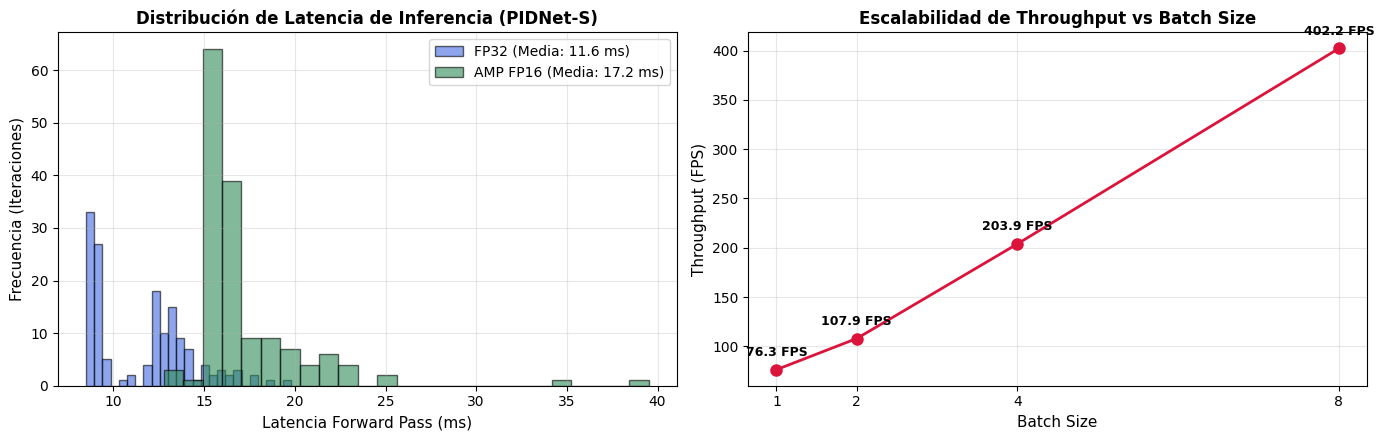

                   RESUMEN CONSOLIDADO DE EFICIENCIA                         
 Arquitectura             : PIDNet-S
 Parámetros Totales       : 7.72 M (29.4 MB)
 Dispositivo              : cuda (Tesla T4)
 Latencia Forward (FP32)  : 11.62 ms (86.06 FPS)
 Latencia Forward (FP16)  : 17.20 ms (58.15 FPS)
 Latencia Pipeline E2E    : 14.48 ms (69.05 FPS)

               LÍNEA FORMATEADA PARA LA TABLA II EN main.tex                
\textbf{PIDNet-S} & 3-Ramas (Detalle/Contexto/Borde) & 0.8246 & 0.6660 & 0.7995 & 0.8320 & 0.7690 & \textbf{17.20} & \textbf{58.15} \\


In [ ]:
# ==============================================================================
# 7. GRÁFICOS DE RENDIMIENTO Y GENERADOR DE TABLA II (IEEE LATEX)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# 1. Distribución de Latencias (Histograma / KDE)
axes[0].hist(stats_fp32['raw_latencies'], bins=25, alpha=0.6, color='royalblue', label=f'FP32 (Media: {stats_fp32["mean"]:.1f} ms)', edgecolor='black')
if stats_fp16 is not None:
    axes[0].hist(stats_fp16['raw_latencies'], bins=25, alpha=0.6, color='seagreen', label=f'AMP FP16 (Media: {stats_fp16["mean"]:.1f} ms)', edgecolor='black')
axes[0].set_xlabel('Latencia Forward Pass (ms)', fontsize=11)
axes[0].set_ylabel('Frecuencia (Iteraciones)', fontsize=11)
axes[0].set_title('Distribución de Latencia de Inferencia (PIDNet-S)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Curva de Throughput (FPS) vs Batch Size
bs_vals = [r['batch_size'] for r in batch_results]
fps_vals = [r['fps'] for r in batch_results]
axes[1].plot(bs_vals, fps_vals, marker='o', color='crimson', lw=2, markersize=8)
axes[1].set_xlabel('Batch Size', fontsize=11)
axes[1].set_ylabel('Throughput (FPS)', fontsize=11)
axes[1].set_title('Escalabilidad de Throughput vs Batch Size', fontsize=12, fontweight='bold')
axes[1].set_xticks(bs_vals)
axes[1].grid(True, alpha=0.3)
for x, y in zip(bs_vals, fps_vals):
    axes[1].annotate(f'{y:.1f} FPS', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Resumen Consolidado y Generador de Código LaTeX para el Paper IEEE (main.tex)
# ─────────────────────────────────────────────────────────────────────────────
lat_rep = stats_fp16['mean'] if (stats_fp16 is not None) else stats_fp32['mean']
fps_rep = stats_fp16['fps'] if (stats_fp16 is not None) else stats_fp32['fps']

print("=" * 80)
print("                   RESUMEN CONSOLIDADO DE EFICIENCIA                         ")
print("=" * 80)
print(f" Arquitectura             : PIDNet-{VARIANT}")
print(f" Parámetros Totales       : {total_params / 1e6:.2f} M ({param_mb:.1f} MB)")
print(f" Dispositivo              : {device} ({torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU'})")
print(f" Latencia Forward (FP32)  : {stats_fp32['mean']:.2f} ms ({stats_fp32['fps']:.2f} FPS)")
if stats_fp16 is not None:
    print(f" Latencia Forward (FP16)  : {stats_fp16['mean']:.2f} ms ({stats_fp16['fps']:.2f} FPS)")
print(f" Latencia Pipeline E2E    : {stats_e2e['mean']:.2f} ms ({stats_e2e['fps']:.2f} FPS)")
print("=" * 80)
